## Cat vs Dog CNN Model

Dataset Overview 

* Training images:8,005
* testing images: 2,023
* classes:
* cats = 0
* Dogs = 1
## Model perfomance

- Test Accuaracy: 80.82%
- Test Loss: 0.4462
This means the model correctly classifies approximately 81 out of every 100 images. This is a good result for a basic CNN model.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
# step 2 :Data preproceessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)
    

In [14]:
train_path =r"C:\Users\BEST\Documents\archive (1)\training_set\training_set"
test_path =r"C:\Users\BEST\Documents\archive (1)\test_set\test_set"

In [15]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size =(128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [16]:
test_data= test_gen.flow_from_directory(
    test_path,
    target_size =(128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [17]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation = "relu",
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation = "relu"
    )
)

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))



In [18]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Summary
- The CNN model has 8 layers: Conv2D,Maxpooling, Flatten, Dense, Dropout, and Output layer.
- The model has 7,392,449 total parameters, all are trainable.
- The first Conv2D layer learn basic image features like edges and colors.
-MaxPooling layers reduce image size and keep important features
-Flatten convertd image  features into a 1D format for classification.
- The Dense layer has the highest parameters, so most learnig happens there.
-Dropout helps reduce overfitting.
- Final  Dense layer has 1 nueron With sigmoide,so it predicts Cat and Dog.

In [20]:
# Step 6: Early stopping

es = EarlyStopping(
    monitor = 'val_loss',patience = 3,
    restore_best_weights = True
)

In [ ]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 165s 646ms/step - accuracy: 0.5975 - loss: 0.6732 - val_accuracy: 0.7034 - val_loss: 0.6083
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 157s 627ms/step - accuracy: 0.6821 - loss: 0.6064 - val_accuracy: 0.6975 - val_loss: 0.5792
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 596ms/step - accuracy: 0.6912 - loss: 0.5884 - val_accuracy: 0.7276 - val_loss: 0.5493
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.7315 - loss: 0.5393 - val_accuracy: 0.7098 - val_loss: 0.5634
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.7418 - loss: 0.5217 - val_accuracy: 0.7573 - val_loss: 0.4975
Epoch 6/20
104/251 ━━━━━━━━━━━━━━━━━━━━ 1:21 553ms/step - accuracy: 0.7746 - loss: 0.4833

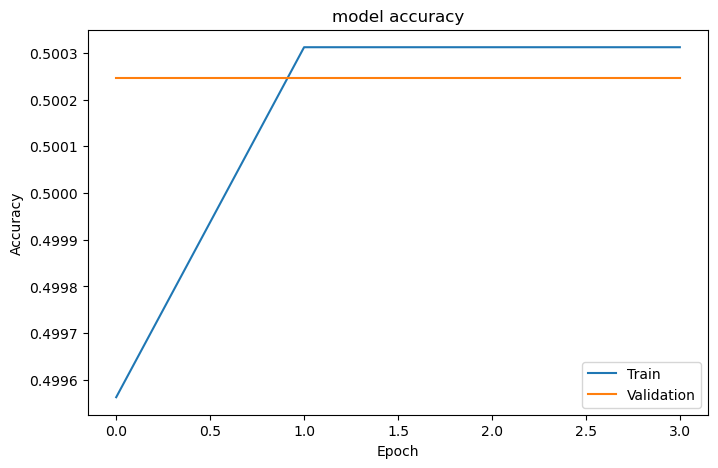

In [11]:
#step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

## Accuracy Graph

* Training accuracy increased from 53.7% to 84.6% , showing the model learned important image features over time.
* Validation accuracy improved from 64.7% to 80.4 %, Indicating good performance on unseen images.
* Both training and validation accuracy curves rise steadily, which suggest effective learning.
* The gap between training accuracy (84.6%) and validation accuracy (80.4%) is small(~4%), indicating minimal overfitting.
* Validation accuracy becomes stable after around Epoch 14-15, meaning the model has largely converged.
* Data augmentation and dropout helped improve generalization and prevent overfitting.
* The final validation accuracy of 80% + shows the CNN model can reliably classify cats and dogs.

In [ ]:
# step 8 : Loss Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

## Loss Graph Insights
- Training loss decreased from 0.70 to 0.35, showing the model learned effectively during training.
- Validation loss decreased from 0.66 to 0.45, indicating improved performance on unseen data.
- Both curves show a downward trend, which means the model is successfully minimizing prediction errors.
- The validation loss remains slightly higher than the training loss, which is expected in real-world models.
- There is only a small gap between training and validation loss, indicating minimal overfitting.
- Around Epoch 14–16, validation loss becomes stable, suggesting the model has reached optimal learning.
- The final loss values indicate that the CNN model generalizes well to new cat and dog images.

In [ ]:
# step 9 : Evaluate model

loss,acc=model.evaluate(test_data)

print("Accuracy", acc)
print("Loss", loss)

In [33]:
# step 10 : save model

model.save("cat_dog-cnn.h5")
print("Model saved successfully")


Model saved successfully


In [ ]:
# step 11 : load model

model = load_model("cat_dog_cnn.h5")

In [ ]:
# Step 12: predict new Images

img_path = r"C:\Users\user\Downloads\catt.jpg"

img = image.load_img(
    img_path,
    target_size = (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis = 0)

pred = model.predict(img_arr)

print("prediction Score:", pred[0][0])

In [ ]:
# Step 13: Final prediction

if pred[0][0] < 0.5:
    print("Dog")
else:
    print("Cat")

In [ ]:
pip install pillow-avif-plugin

In [ ]:
import pillow-avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("cat_dog_cnn.h5")
img_path = 

img = img.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.extend_dims(img_arr,axis=0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")